In [1]:
#Import library
import numpy as np 
import pandas as pd
import tensorflow as tf
import sklearn
import sys

import matplotlib
import matplotlib.pyplot as plt
import joblib as jl

import os
import random

from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.utils import class_weight

print("Python:",sys.version)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Joblib:", jl.__version__)

Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
Numpy: 1.24.3
Pandas: 2.2.3
TensorFlow: 2.12.1
Scikit-learn: 1.6.1
Matplotlib: 3.8.4
Joblib: 1.1.0


In [2]:
# Kunci semua seed agar hasil selalu sama
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
#Memuat Dataset
data = pd.read_csv("DATASET_ITCLEAN.csv", encoding="utf-8-sig")

In [4]:
#Drop kolom yang tidak terpakai
data = data.drop(columns=[
    "No", "Nama Mahasiswa", "Kampus", "Prodi", "Semester (1-6)"
])

In [5]:
#Ubah kolom IPK jadi numerik
data["IPK"] = pd.to_numeric(
    data["IPK"], errors="coerce")

In [6]:
# Buang data yang IPK-nya kosong
data = data.dropna(subset=["IPK"])
print(data["IPK"].isnull().sum())

0


In [7]:
dataNum = data.select_dtypes("number")

List cleaning Data
- Innacurate Value
- Innacurate Data Type
- Missing Value
- Duplicate
- Outlier
- Skewness

In [8]:
q3 = dataNum.quantile(0.75)
q1 = dataNum.quantile(0.25)
iqr = q3 - q1
print(iqr)
Ba = q3 *1.5
Bb = q1 *1.5

Durasi Tidur (jam)             1.0
Rata-Rata Screentime (0-9)     3.0
Fekuensi Malam Minggu (0-3)    1.0
Waktu Belajar (0-8)            2.0
IPK                            1.0
dtype: float64


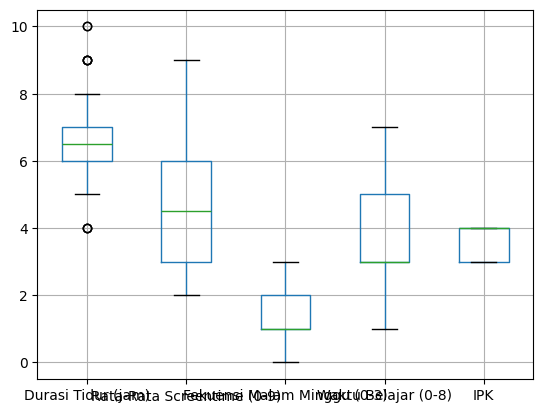

In [9]:
dataNum.boxplot()
plt.show()

In [10]:
# Kategori Kecukupan Tidur
def durasi_tdr(jam):
    if jam < 6:
        return 0  # Kurang
    elif jam <= 8:
        return 1  # Cukup
    else:
        return 2  # Lebih

data["Jam Tidur"] = pd.to_datetime(data["Jam Tidur"])
data["Jam Bangun"] = pd.to_datetime(data["Jam Bangun"])

cukup_tidur = ((data["Jam Bangun"] - data["Jam Tidur"]).dt.total_seconds() / 3600).apply(durasi_tdr)
data.insert(0, "Kecukupan Tidur", cukup_tidur)

In [11]:
# Kategori Berdasarkan IPK
def kategori_ipk(ipk):
    if ipk >= 3.6:
        return "Jenius"
    elif ipk >= 3.3:
        return "Biasa Aja"
    else:
        return "Bebel"

data["Kategori"] = data["IPK"].apply(kategori_ipk)
data.T

,6,21,43,67,80,82,91,93,104,121,...,451,476,497,519,522,537,552,570,572,590
Kecukupan Tidur,2,1,2,1,1,2,1,2,2,1,...,1,2,1,1,1,1,1,1,1,0
Jam Tidur,1899-12-30 00:00:00,1899-12-30 23:00:00,1899-12-30 22:00:00,1899-12-30 23:00:00,1899-12-30 21:00:00,1899-12-30 00:00:00,1899-12-30 23:00:00,1899-12-30 01:00:00,1899-12-30 02:00:00,1899-12-30 23:00:00,...,1899-12-30 22:00:00,1899-12-30 00:00:00,1899-12-30 22:00:00,1899-12-30 23:00:00,1899-12-30 22:00:00,1899-12-30 22:00:00,1899-12-30 22:00:00,1899-12-30 21:00:00,1899-12-30 23:00:00,1899-12-30 23:00:00
Jam Bangun,1899-12-31 07:00:00,1899-12-31 05:00:00,1899-12-31 07:00:00,1899-12-31 06:00:00,1899-12-31 04:00:00,1899-12-31 06:00:00,1899-12-31 05:00:00,1899-12-31 10:00:00,1899-12-31 10:00:00,1899-12-31 06:00:00,...,1899-12-31 05:00:00,1899-12-31 10:00:00,1899-12-31 04:00:00,1899-12-31 05:00:00,1899-12-31 04:00:00,1899-12-31 04:00:00,1899-12-31 04:00:00,1899-12-31 05:00:00,1899-12-31 05:00:00,1899-12-31 03:00:00
Durasi Tidur (jam),7,6,9,7,7,6,6,9,8,7,...,7,10,6,6,6,6,6,8,6,4
Rata-Rata Screentime (0-9),6,4,9,2,7,5,3,5,6,4,...,5,6,4,5,2,4,3,8,5,9
Punya Pacar (Ya atau Tidak),Tidak,Tidak,Tidak,Tidak,Tidak,Ya,Tidak,Tidak,Tidak,Ya,...,Tidak,Ya,Ya,Ya,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak
Fekuensi Malam Minggu (0-3),1,2,2,1,1,1,1,0,2,3,...,1,1,1,2,1,2,1,2,1,2
Bermain Judol (Ya atau Tidak),Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,...,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak
Waktu Belajar (0-8),3,1,5,5,3,5,1,7,5,4,...,1,3,7,5,3,3,2,5,3,1
Pekerjaan Sampingan (Ya atau Tidak),Tidak,Ya,Tidak,Tidak,Tidak,Tidak,Ya,Tidak,Tidak,Tidak,...,Tidak,Ya,Tidak,Tidak,Tidak,Tidak,Tidak,Ya,Ya,Ya


In [12]:
data = data.drop(columns=["IPK"])
data = data.drop(columns=["Jam Tidur"])
data = data.drop(columns=["Jam Bangun"])

data.T

,6,21,43,67,80,82,91,93,104,121,...,451,476,497,519,522,537,552,570,572,590
Kecukupan Tidur,2,1,2,1,1,2,1,2,2,1,...,1,2,1,1,1,1,1,1,1,0
Durasi Tidur (jam),7,6,9,7,7,6,6,9,8,7,...,7,10,6,6,6,6,6,8,6,4
Rata-Rata Screentime (0-9),6,4,9,2,7,5,3,5,6,4,...,5,6,4,5,2,4,3,8,5,9
Punya Pacar (Ya atau Tidak),Tidak,Tidak,Tidak,Tidak,Tidak,Ya,Tidak,Tidak,Tidak,Ya,...,Tidak,Ya,Ya,Ya,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak
Fekuensi Malam Minggu (0-3),1,2,2,1,1,1,1,0,2,3,...,1,1,1,2,1,2,1,2,1,2
Bermain Judol (Ya atau Tidak),Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,...,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak,Tidak
Waktu Belajar (0-8),3,1,5,5,3,5,1,7,5,4,...,1,3,7,5,3,3,2,5,3,1
Pekerjaan Sampingan (Ya atau Tidak),Tidak,Ya,Tidak,Tidak,Tidak,Tidak,Ya,Tidak,Tidak,Tidak,...,Tidak,Ya,Tidak,Tidak,Tidak,Tidak,Tidak,Ya,Ya,Ya
Kategori,Bebel,Bebel,Jenius,Bebel,Jenius,Bebel,Bebel,Jenius,Bebel,Jenius,...,Jenius,Jenius,Jenius,Bebel,Jenius,Jenius,Jenius,Jenius,Bebel,Bebel


In [13]:
# Encode fitur kategorikal
label_encoders = {}
for col in data.columns:
    if data[col].dtype == "object" and col != "Kategori":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

In [14]:
# Split fitur dan label
X = data.drop(columns=["Kategori"]).values
Y = data["Kategori"].values
unique, counts = np.unique(Y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label} : {count} data")

Bebel : 19 data
Jenius : 23 data


In [15]:
# One-hot encoding untuk label
lb = LabelBinarizer()
Y = lb.fit_transform(Y)
if Y.shape[1] == 1:
    Y = np.hstack((1 - Y, Y))
jl.dump(lb, 'label_binarizer.save')

['label_binarizer.save']

In [16]:
# Split data training dan testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state = seed)

In [17]:
# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
jl.dump(sc, 'scaler.save')

['scaler.save']

In [18]:
# Membangun ANN
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(64, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dropout(0.3))
ann.add(tf.keras.layers.Dense(128, activation='relu'))
ann.add(Dropout(0.3))
ann.add(tf.keras.layers.Dense(64, activation='relu'))
ann.add(Dropout(0.3))
ann.add(tf.keras.layers.Dense(Y.shape[1], activation='softmax'))

In [19]:
# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
ann.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
# Training model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = ann.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/100


ValueError: in user code:

    File "C:\Users\polte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\engine\training.py", line 1284, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\polte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\engine\training.py", line 1268, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\polte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\engine\training.py", line 1249, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\polte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\engine\training.py", line 1051, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\Users\polte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\engine\training.py", line 1109, in compute_loss
        return self.compiled_loss(
    File "C:\Users\polte\

In [ ]:
# Membuat plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Membuat plot Akurasi
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = ann.evaluate(X_test, Y_test)
print(f"Loss Validation: {loss:.4f}")
print(f"Akurasi Validation: {accuracy:.4f}")

## Revisi reviewer: metrik tambahan (ANN)

Precision, recall, F1-score, specificity, ROC-AUC, dan confusion matrix pada hold-out test set untuk model ANN yang baru dilatih.

In [ ]:
# Metrik lengkap ANN pada hold-out test set
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

class_names = list(lb.classes_)
n_classes = len(class_names)
y_true = np.argmax(Y_test, axis=1)
y_proba_ann = ann.predict(X_test, verbose=0)
y_pred_ann = np.argmax(y_proba_ann, axis=1)
pos = n_classes - 1  # kelas dengan IPK tertinggi (urutan LabelBinarizer)

cm_ann = confusion_matrix(y_true, y_pred_ann, labels=np.arange(n_classes))


def specificity_from_cm(cm, i):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    return tn / (tn + fp) if (tn + fp) else np.nan


if n_classes == 2:
    kw = dict(pos_label=pos, zero_division=0)
    spec = specificity_from_cm(cm_ann, pos)
    auc = roc_auc_score(y_true, y_proba_ann[:, pos])
else:
    kw = dict(average="macro", zero_division=0)
    spec = float(np.nanmean([specificity_from_cm(cm_ann, i) for i in range(n_classes)]))
    auc = roc_auc_score(y_true, y_proba_ann, multi_class="ovr", average="macro")

print("Hold-out test set — ANN (Proposed)")
print(f"Accuracy    : {accuracy_score(y_true, y_pred_ann):.4f}")
print(f"Precision   : {precision_score(y_true, y_pred_ann, **kw):.4f}")
print(f"Recall      : {recall_score(y_true, y_pred_ann, **kw):.4f}")
print(f"F1-score    : {f1_score(y_true, y_pred_ann, **kw):.4f}")
print(f"Specificity : {spec:.4f}")
print(f"ROC-AUC     : {auc:.4f}")
print("\nClassification report:\n")
print(classification_report(y_true, y_pred_ann, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_ann, display_labels=class_names).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title("Confusion Matrix — ANN")
plt.tight_layout()
plt.show()

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_proba_ann[:, pos], pos_label=pos)
    plt.figure(figsize=(5, 4.5))
    plt.plot(fpr, tpr, label=f"ANN (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve — kelas positif: {class_names[pos]}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
#Save Model ANN
ann.save("test.h5")

In [ ]:
# Tiga variasi input untuk menguji prediksi
"""Urutan : Tidur (0-5 am, 6-11 pm), Bangun (0-12), Screentime (0-18), Pacar (Ya:1 atau Tidak:0), Sosial (0-3), Judol (Ya:1 atau Tidak:0), 
            Waktu Belajar (0-12), Kerja sambilan (Ya:1 atau tidak:0)"""

input_jenius = [[9, 5, 1, 0, 1, 0, 12, 0]]  # Pinter Banget
input_biasa  = [[8, 3, 9, 1, 2, 0, 5, 0]]   # Minimal Biasa Aja
input_bebel  = [[6, 12, 18, 1, 3, 1, 0, 1]]  # Bebel Banget
input_anomali  = [[0, 0, 0, 0, 0, 0, 0, 0]]   # Anomali
input_error  = [["a", 5, 1, 0, 1, 0, 12, 0]]  # Error: input huruf

# Fungsi untuk mengecek input
def cek_input_valid(input_data, threshold1=0.8, threshold2=0.6):
    try:
        input_array = np.array(input_data, dtype=float)  # Paksa harus float (akan error kalau ada string)

        total_fitur = input_array.shape[1]
        jumlah_nol = np.sum(input_array == 0)

        # Cek nilai negatif
        if np.any(input_array < 0):
            return "invalid_negatif"

        # Cek semua 0
        if jumlah_nol == total_fitur:
            return "invalid_semua_0"

        # Cek banyak nol
        if (jumlah_nol / total_fitur) >= threshold1:
            return "peringatan_kebanyakan_0_1"

        if (jumlah_nol / total_fitur) >= threshold2:
            return "peringatan_kebanyakan_0_2"
        
        return "valid"
    
    except ValueError:
        return "invalid_format"  # Kalau ada input bukan angka

# Contoh list input
input_list = [
    ("Jenius", input_jenius),
    ("Biasa Aja", input_biasa),
    ("Bebel", input_bebel),
    ("Anomali", input_anomali),
    ("Error", input_error)
]

print("{:<12} {:<20} {:<50}".format("Target", "Prediksi", "Probabilitas [Bebel, Biasa Aja, Jenius]"))
print("="*85)

for label, input_data in input_list:
    try:
        status = cek_input_valid(input_data)

        if status == "invalid_format":
            print(f"{label:<12} {'Input format salah':<20} {'(Ada data bukan angka)':<50}")
            continue

        if status == "invalid_negatif":
            print(f"{label:<12} {'Input tidak valid':<20} {'(Ada nilai negatif)':<50}")
            continue

        if status == "invalid_semua_0":
            print(f"{label:<12} {'Input tidak valid':<20} {'(Semua fitur 0)':<50}")
            continue

        if status == "peringatan_kebanyakan_0_1" or status == "peringatan_kebanyakan_0_2":
            print(f"{label:<12} {'Warning banyak 0':<20} {'(Hasil prediksi mungkin tidak akurat)':<50}")
            continue

        input_array = np.array(input_data, dtype=float)  # Konversi aman di sini
        input_scaled = sc.transform(input_array)
        prediction = ann.predict(input_scaled, verbose=0)

        predicted_class_index = np.argmax(prediction, axis=-1)
        predicted_label = lb.classes_[predicted_class_index[0]]
        
        probas = np.round(prediction[0], 4)

        print(f"{label:<12} {predicted_label:<20} {str(probas):<50}")
    
    except Exception as e:
        print(f"{label:<12} {'Error saat prediksi':<20} {str(e):<50}")

## Revisi reviewer: perbandingan model, k-fold CV, dan explainability

Semua classifier memakai preprocessing identik (`StandardScaler` di-fit hanya pada data latih tiap fold). ANN dibungkus API scikit-learn agar fold dan metriknya sama dengan baseline.

In [ ]:
# Library pembanding + XAI (lewati yang belum terpasang)
# %pip install xgboost lightgbm catboost shap

import warnings
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except Exception:
    HAS_LGB = False
try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception:
    HAS_CAT = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

print("XGBoost :", HAS_XGB, "| LightGBM :", HAS_LGB, "| CatBoost :", HAS_CAT, "| SHAP :", HAS_SHAP)


In [ ]:
# Label integer, nama fitur, dan wrapper ANN (arsitektur manuskrip)
FEATURE_NAMES = [c for c in data.columns if c != "Kategori"]
class_names = list(lb.classes_)
y = np.argmax(Y, axis=1)
N_CLASSES = Y.shape[1]
POS_LABEL = N_CLASSES - 1
N_SPLITS, N_REPEATS = 5, 5  # 25 estimasi per model

print("Fitur :", FEATURE_NAMES)
print("Kelas :", class_names, "| positif:", class_names[POS_LABEL])
print("n     :", len(y), "| distribusi:", dict(zip(class_names, np.bincount(y))))


def build_ann(input_dim, n_out, dropout=0.3, lr=0.0005):
    tf.keras.backend.clear_session()
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(n_out, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


class KerasANNClassifier(BaseEstimator, ClassifierMixin):
    """ANN Keras dengan antarmuka scikit-learn (early stopping tanpa data uji)."""

    def __init__(self, epochs=100, batch_size=32, dropout=0.3, lr=0.0005,
                 patience=5, val_split=0.2, seed=42, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.dropout = dropout
        self.lr = lr
        self.patience = patience
        self.val_split = val_split
        self.seed = seed
        self.verbose = verbose

    def fit(self, X, y):
        os.environ["PYTHONHASHSEED"] = str(self.seed)
        random.seed(self.seed)
        np.random.seed(self.seed)
        tf.random.set_seed(self.seed)

        X = np.asarray(X, dtype="float32")
        y = np.asarray(y)
        rng = np.random.RandomState(self.seed)
        idx = rng.permutation(len(X))
        X, y = X[idx], y[idx]

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        Yh = tf.keras.utils.to_categorical(
            np.searchsorted(self.classes_, y), num_classes=self.n_classes_
        )
        self.model_ = build_ann(X.shape[1], self.n_classes_, self.dropout, self.lr)

        fit_kw, monitor = {}, "loss"
        if self.val_split and int(len(X) * self.val_split) >= self.n_classes_:
            fit_kw["validation_split"] = self.val_split
            monitor = "val_loss"
        self.model_.fit(
            X, Yh, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose,
            callbacks=[EarlyStopping(monitor=monitor, patience=self.patience,
                                     restore_best_weights=True)],
            **fit_kw,
        )
        return self

    def predict_proba(self, X):
        return self.model_.predict(np.asarray(X, dtype="float32"), verbose=0)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def get_models():
    models = {
        "ANN (Proposed)": KerasANNClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=5000, random_state=seed),
        "Decision Tree": DecisionTreeClassifier(random_state=seed),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=seed),
        "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=seed),
        "MLP (sklearn)": MLPClassifier(
            hidden_layer_sizes=(64, 128, 64), max_iter=3000, random_state=seed
        ),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9,
            colsample_bytree=0.9, eval_metric="logloss", random_state=seed, verbosity=0,
        )
    if HAS_LGB:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3, num_leaves=7,
            min_child_samples=5, random_state=seed, verbose=-1,
        )
    if HAS_CAT:
        models["CatBoost"] = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=4, random_seed=seed, verbose=0,
        )
    return models


def make_pipe(model):
    return Pipeline([("scaler", StandardScaler()), ("clf", model)])


print("Model:", list(get_models()))


In [ ]:
# Fungsi metrik (dipakai hold-out dan setiap fold CV)
METRIC_ORDER = [
    "Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-score", "ROC-AUC"
]


def specificity_from_cm(cm, i):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    return tn / (tn + fp) if (tn + fp) else np.nan


def compute_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
    spec_cls = [specificity_from_cm(cm, i) for i in range(N_CLASSES)]
    if N_CLASSES == 2:
        kw = dict(pos_label=POS_LABEL, zero_division=0)
        spec = spec_cls[POS_LABEL]
        try:
            auc_v = roc_auc_score(y_true, y_proba[:, POS_LABEL])
        except ValueError:
            auc_v = np.nan
    else:
        kw = dict(average="macro", zero_division=0)
        spec = float(np.nanmean(spec_cls))
        try:
            auc_v = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        except ValueError:
            auc_v = np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, **kw),
        "Recall (Sensitivity)": recall_score(y_true, y_pred, **kw),
        "Specificity": spec,
        "F1-score": f1_score(y_true, y_pred, **kw),
        "ROC-AUC": auc_v,
    }


In [ ]:
# Hold-out: semua model, preprocessing identik (split yang sama dengan ANN)
X_tr_raw = sc.inverse_transform(X_train)
X_te_raw = sc.inverse_transform(X_test)
y_tr = np.argmax(Y_train, axis=1)
y_te = np.argmax(Y_test, axis=1)

fitted, holdout_rows, roc_data = {}, [], {}
for name, model in get_models().items():
    pipe = make_pipe(clone(model))
    pipe.fit(X_tr_raw, y_tr)
    yp, ys = pipe.predict(X_te_raw), pipe.predict_proba(X_te_raw)
    fitted[name] = pipe
    rec = {"Model": name}
    rec.update(compute_metrics(y_te, yp, ys))
    holdout_rows.append(rec)
    if N_CLASSES == 2:
        fpr, tpr, _ = roc_curve(y_te, ys[:, POS_LABEL], pos_label=POS_LABEL)
        roc_data[name] = (fpr, tpr, rec["ROC-AUC"])
    print("selesai:", name)

holdout = pd.DataFrame(holdout_rows).set_index("Model")
holdout = holdout.loc[holdout["F1-score"].sort_values(ascending=False).index]
print("\nHold-out test set (preprocessing identik)\n")
print(holdout[METRIC_ORDER].round(3).to_string())


In [ ]:
# Confusion matrix & kurva ROC semua model (hold-out)
n_m = len(fitted)
ncols = 3
nrows = int(np.ceil(n_m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_te, pipe.predict(X_te_raw), labels=np.arange(N_CLASSES))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(name, fontsize=10)
for ax in axes[n_m:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

if N_CLASSES == 2:
    plt.figure(figsize=(6.8, 6))
    for name, (fpr, tpr, auc_v) in sorted(roc_data.items(), key=lambda kv: -kv[1][2]):
        plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC = {auc_v:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC — hold-out (positif: {class_names[POS_LABEL]})")
    plt.legend(fontsize=8, loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Repeated stratified k-fold CV (mean ± SD dan 95% CI)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=seed)
splits = list(cv.split(X, y))
print(f"{N_SPLITS}-fold × {N_REPEATS} repeat = {len(splits)} fold per model\n")

rows = []
for name, model in get_models().items():
    for fold_id, (tr, te) in enumerate(splits):
        pipe = make_pipe(clone(model))
        pipe.fit(X[tr], y[tr])
        rec = {"Model": name, "Fold": fold_id}
        rec.update(compute_metrics(y[te], pipe.predict(X[te]), pipe.predict_proba(X[te])))
        rows.append(rec)
    print("selesai:", name)

cv_results = pd.DataFrame(rows)


def mean_ci(values, confidence=0.95):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    n = len(v)
    mean, sd = v.mean(), v.std(ddof=1)
    half = stats.t.ppf((1 + confidence) / 2, n - 1) * sd / np.sqrt(n)
    return mean, sd, mean - half, mean + half


report_rows, numeric_rows = [], []
for name in get_models():
    sub = cv_results[cv_results["Model"] == name]
    rrow, nrow = {"Model": name}, {"Model": name}
    for m in METRIC_ORDER:
        mean, sd, lo, hi = mean_ci(sub[m].values)
        rrow[m] = f"{mean:.3f} ± {sd:.3f} [{lo:.3f}, {hi:.3f}]"
        nrow[m] = mean
        nrow[f"{m} sd"] = sd
    report_rows.append(rrow)
    numeric_rows.append(nrow)

cv_report = pd.DataFrame(report_rows).set_index("Model")
cv_num = pd.DataFrame(numeric_rows).set_index("Model").sort_values("F1-score", ascending=False)
cv_report = cv_report.loc[cv_num.index]

print(f"\n{N_SPLITS}-fold × {N_REPEATS} repeat CV — mean ± SD [95% CI]\n")
print(cv_report.to_string())

order = cv_num.index.tolist()
xpos = np.arange(len(order))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(["Accuracy", "F1-score", "ROC-AUC"]):
    ax.bar(xpos + (i - 1) * width, cv_num[m].values, width,
           yerr=cv_num[f"{m} sd"].values, capsize=3, label=m)
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor")
ax.set_title(f"Perbandingan model — {N_SPLITS}-fold × {N_REPEATS} repeat CV (mean ± SD)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Permutation importance — ANN (hold-out) dan rata-rata antar model
class _ProbaWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model=None, classes=None):
        self.keras_model = keras_model
        self.classes = classes

    def fit(self, X, y):
        self.classes_ = np.asarray(self.classes)
        return self

    def predict_proba(self, X_):
        return self.keras_model.predict(np.asarray(X_, dtype="float32"), verbose=0)

    def predict(self, X_):
        return self.classes_[np.argmax(self.predict_proba(X_), axis=1)]


def _xai_score(estimator, X_, y_):
    proba = estimator.predict_proba(X_)
    if N_CLASSES == 2:
        return roc_auc_score(y_, proba[:, POS_LABEL])
    return roc_auc_score(y_, proba, multi_class="ovr", average="macro")


ann_wrap = _ProbaWrapper(ann, np.arange(N_CLASSES)).fit(X_test, y_te)
scoring = _xai_score
pi_ann = permutation_importance(
    ann_wrap, X_test, y_te, scoring=scoring, n_repeats=20, random_state=seed
)
pi_ann_df = pd.DataFrame({
    "Fitur": FEATURE_NAMES,
    "Importance": pi_ann.importances_mean,
    "SD": pi_ann.importances_std,
}).sort_values("Importance")

score_name = "ROC-AUC" if N_CLASSES == 2 else "ROC-AUC macro"
print(f"Permutation importance ANN (penurunan {score_name} pada test set)\n")
print(pi_ann_df.sort_values("Importance", ascending=False).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(pi_ann_df["Fitur"], pi_ann_df["Importance"], xerr=pi_ann_df["SD"],
        capsize=3, color="#2f6fb5")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"Penurunan {score_name} saat fitur dipermutasi")
ax.set_title("Permutation Importance — ANN")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Permutation importance semua model (satu kali, hold-out, preprocessing identik)
pi_rows = []
for name, pipe in fitted.items():
    r = permutation_importance(
        pipe, X_te_raw, y_te, scoring=scoring, n_repeats=15, random_state=seed, n_jobs=1
    )
    for i, f in enumerate(FEATURE_NAMES):
        pi_rows.append({"Model": name, "Fitur": f, "Importance": r.importances_mean[i]})
    print("selesai:", name)

pi_table = pd.DataFrame(pi_rows).pivot_table(
    index="Fitur", columns="Model", values="Importance", aggfunc="mean"
)
pi_table["Rata-rata"] = pi_table.mean(axis=1)
pi_table = pi_table.sort_values("Rata-rata", ascending=False)
print("\nPermutation importance antar model\n")
print(pi_table.round(4).to_string())


In [ ]:
# SHAP — penjelasan global dan lokal untuk ANN
# %pip install shap
import shap

FIG_DIR = "figures_revisi"
TAB_DIR = "tables_revisi"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

FEATURE_NAMES = [c for c in data.columns if c != "Kategori"]
class_names = list(lb.classes_)
N_CLASSES = Y.shape[1]
POS_LABEL = N_CLASSES - 1
y_te = np.argmax(Y_test, axis=1)
y_proba_ann = ann.predict(X_test, verbose=0)
X_test_orig = sc.inverse_transform(X_test)

background = shap.kmeans(X_train, min(25, len(X_train)))

def f_pos(z):
    return ann.predict(np.asarray(z, dtype="float32"), verbose=0)[:, POS_LABEL]

explainer = shap.KernelExplainer(f_pos, background)
shap_ann = np.asarray(explainer.shap_values(X_test, nsamples="auto", silent=True))
if shap_ann.ndim == 3:
    shap_ann = shap_ann[:, :, POS_LABEL]

# 1) Beeswarm (global)
shap.summary_plot(shap_ann, X_test_orig, feature_names=FEATURE_NAMES, show=False)
plt.title(f"SHAP beeswarm — ANN (kelas '{class_names[POS_LABEL]}')")
plt.savefig(os.path.join(FIG_DIR, "fig_shap_beeswarm_ann.png"), dpi=300, bbox_inches="tight")
plt.show()

# 2) Bar |SHAP| (global ranking)
shap.summary_plot(shap_ann, X_test_orig, feature_names=FEATURE_NAMES, plot_type="bar", show=False)
plt.title("SHAP — rata-rata |nilai SHAP| (ANN)")
plt.savefig(os.path.join(FIG_DIR, "fig_shap_bar_ann.png"), dpi=300, bbox_inches="tight")
plt.show()

shap_mean = pd.Series(np.abs(shap_ann).mean(axis=0), index=FEATURE_NAMES).sort_values(ascending=False)
shap_mean.to_csv(os.path.join(TAB_DIR, "shap_mean_abs_ann.csv"), header=["mean_abs_shap"])
print("Rata-rata |SHAP| per fitur (ANN)\n")
print(shap_mean.round(4).to_string())

# 3) Waterfall + decision plot (lokal, sampel uji pertama)
i = 0
proba_i = y_proba_ann[i]
print(f"\nPenjelasan lokal — sampel uji #{i}")
print("  Aktual        :", class_names[y_te[i]])
print("  Prediksi ANN  :", class_names[int(np.argmax(proba_i))])
print("  Probabilitas  :", dict(zip(class_names, np.round(proba_i, 4))))
for f_name, f_val, s_val in zip(FEATURE_NAMES, X_test_orig[i], shap_ann[i]):
    arah = "menaikkan" if s_val > 0 else "menurunkan"
    print(f"    {f_name:<36} = {f_val:>6.2f}  SHAP = {s_val:+.4f}  ({arah} P({class_names[POS_LABEL]}))")

exp_i = shap.Explanation(
    values=shap_ann[i],
    base_values=float(np.asarray(explainer.expected_value).reshape(-1)[0]),
    data=X_test_orig[i],
    feature_names=FEATURE_NAMES,
)
shap.plots.waterfall(exp_i, show=False)
plt.title(f"SHAP waterfall — sampel uji #{i}")
plt.savefig(os.path.join(FIG_DIR, "fig_shap_waterfall_ann.png"), dpi=300, bbox_inches="tight")
plt.show()

shap.decision_plot(
    explainer.expected_value, shap_ann[i],
    pd.Series(X_test_orig[i], index=FEATURE_NAMES), show=False,
)
plt.title(f"SHAP decision plot — sampel uji #{i}")
plt.savefig(os.path.join(FIG_DIR, "fig_shap_lokal_sampel.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nGambar SHAP disimpan di:")
print("  figures_revisi/fig_shap_beeswarm_ann.png")
print("  figures_revisi/fig_shap_bar_ann.png")
print("  figures_revisi/fig_shap_waterfall_ann.png")
print("  figures_revisi/fig_shap_lokal_sampel.png")
print("  tables_revisi/shap_mean_abs_ann.csv")
